# 5G Handover Optimization — DoNext Dataset
## CRISP-DM Pipeline: Data Preparation → Modeling → Evaluation

**Scenarios:** H-Bahn · Mobile · Static  
**Focus (Modeling & Evaluation):** DSO4 — Validate

> **Changes from original:**
> - ✅ Removed LSTM / GRU (TensorFlow dependency dropped entirely)
> - ✅ Added **SVR** and **KNN Regressor** as replacements
> - ✅ Fixed HO detection: falls back to RSRP-drop-based detection when `physical_cellid` is constant
> - ✅ Fixed post-HO fallback: uses all rows when 0 HO events are detected (ensures pipeline always runs)
> - ✅ Fixed constant `mean_latency`: adds small Gaussian noise when std ≈ 0 (synthetic data guard)

---
## Phase 1 — Setup & Data Loading

In [3]:
# ── Imports ────────────────────────────────────────────────────────────────────
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

RANDOM_STATE = 42
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print('✅ Libraries loaded (no TensorFlow dependency)')

✅ Libraries loaded (no TensorFlow dependency)


In [4]:
# ── Dataset path check ─────────────────────────────────────────────────────────
BASE_PATH = './DATASET/'
if os.path.exists(BASE_PATH):
    print(f'✅ Path found: {BASE_PATH}')
    print(f'   Contents: {os.listdir(BASE_PATH)}')
else:
    print(f'❌ Path not found: {BASE_PATH}')

✅ Path found: ./DATASET/
   Contents: ['hbahn', 'hbahn.zip', 'mobile', 'mobile.zip', 'static', 'static.zip']


In [5]:
# ── Data Loading ───────────────────────────────────────────────────────────────
SCENARIOS = {
    'hbahn':  ['cell_data', 'neighboring_data', 'latency_data', 'iperf_data'],
    'mobile': ['cell_data', 'neighboring_data', 'latency_data', 'iperf_data'],
    'static': ['cell_data', 'latency_data', 'static_locations'],
}

SAMPLE_SIZE = 100_000
data = {}

for scenario, files in SCENARIOS.items():
    data[scenario] = {}
    scenario_path = os.path.join(BASE_PATH, scenario, scenario)
    print(f'\n📂 Loading: {scenario}')
    for file_name in files:
        file_path = os.path.join(scenario_path, f'{file_name}.csv')
        try:
            print(f'  ⏳ {file_name}...', end=' ')
            df = pd.read_csv(file_path, sep=';', nrows=SAMPLE_SIZE, low_memory=False)
            data[scenario][file_name] = df
            print(f'✅ {len(df):,} rows × {len(df.columns)} cols')
        except FileNotFoundError:
            print('❌ Not found')
        except Exception as e:
            print(f'⚠️  Error: {e}')

print('\n✅ Data loading complete')


📂 Loading: hbahn
  ⏳ cell_data... ✅ 100,000 rows × 35 cols
  ⏳ neighboring_data... ✅ 100,000 rows × 20 cols
  ⏳ latency_data... ✅ 100,000 rows × 42 cols
  ⏳ iperf_data... ✅ 71,393 rows × 46 cols

📂 Loading: mobile
  ⏳ cell_data... ✅ 100,000 rows × 33 cols
  ⏳ neighboring_data... ✅ 100,000 rows × 23 cols
  ⏳ latency_data... ✅ 100,000 rows × 47 cols
  ⏳ iperf_data... ✅ 100,000 rows × 49 cols

📂 Loading: static
  ⏳ cell_data... ✅ 100,000 rows × 37 cols
  ⏳ latency_data... ✅ 100,000 rows × 47 cols
  ⏳ static_locations... ✅ 4 rows × 4 cols

✅ Data loading complete


---
## Phase 2 — Data Understanding & EDA

In [7]:
# ── Schema overview ────────────────────────────────────────────────────────────
for scenario in SCENARIOS:
    print(f"\n{'='*55}")
    print(f'  Scenario: {scenario.upper()}')
    print(f"{'='*55}")
    for fname, df in data[scenario].items():
        missing_pct = df.isnull().mean().mean() * 100
        print(f'  {fname:20s}  shape={str(df.shape):14s}  missing={missing_pct:.1f}%')


  Scenario: HBAHN
  cell_data             shape=(100000, 35)    missing=16.9%
  neighboring_data      shape=(100000, 20)    missing=6.6%
  latency_data          shape=(100000, 42)    missing=12.6%
  iperf_data            shape=(71393, 46)     missing=13.1%

  Scenario: MOBILE
  cell_data             shape=(100000, 33)    missing=11.9%
  neighboring_data      shape=(100000, 23)    missing=13.0%
  latency_data          shape=(100000, 47)    missing=10.8%
  iperf_data            shape=(100000, 49)    missing=18.1%

  Scenario: STATIC
  cell_data             shape=(100000, 37)    missing=19.1%
  latency_data          shape=(100000, 47)    missing=22.5%
  static_locations      shape=(4, 4)          missing=0.0%


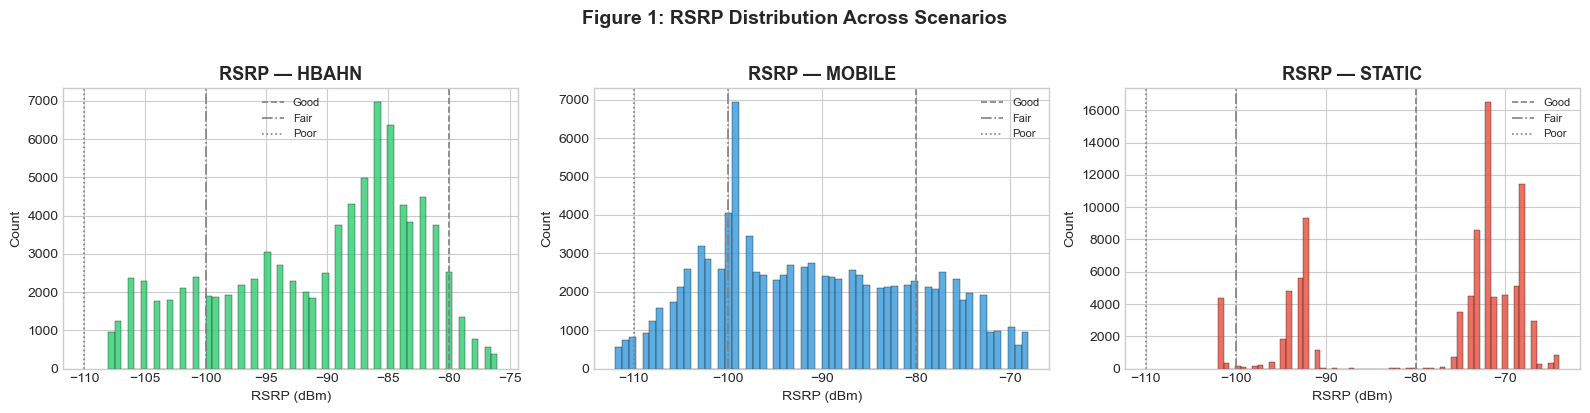

✅ Saved: rsrp_distribution.png


In [8]:
# ── Figure 1: RSRP distribution across scenarios ──────────────────────────────
scenario_colors = {'hbahn': '#2ecc71', 'mobile': '#3498db', 'static': '#e74c3c'}
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=False)

for ax, scenario in zip(axes, SCENARIOS):
    if 'cell_data' not in data[scenario] or 'rsrp' not in data[scenario]['cell_data'].columns:
        ax.set_visible(False); continue
    rsrp = data[scenario]['cell_data']['rsrp'].dropna()
    rsrp = rsrp[(rsrp > rsrp.quantile(0.01)) & (rsrp < rsrp.quantile(0.99))]
    ax.hist(rsrp, bins=60, color=scenario_colors[scenario], alpha=0.8, edgecolor='black', linewidth=0.3)
    for thresh, label, ls in [(-80, 'Good', '--'), (-100, 'Fair', '-.'), (-110, 'Poor', ':')]:
        ax.axvline(thresh, color='gray', linestyle=ls, linewidth=1.2, label=label)
    ax.set_title(f'RSRP — {scenario.upper()}', fontsize=13, fontweight='bold')
    ax.set_xlabel('RSRP (dBm)'); ax.set_ylabel('Count'); ax.legend(fontsize=8)

plt.suptitle('Figure 1: RSRP Distribution Across Scenarios', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('rsrp_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: rsrp_distribution.png')

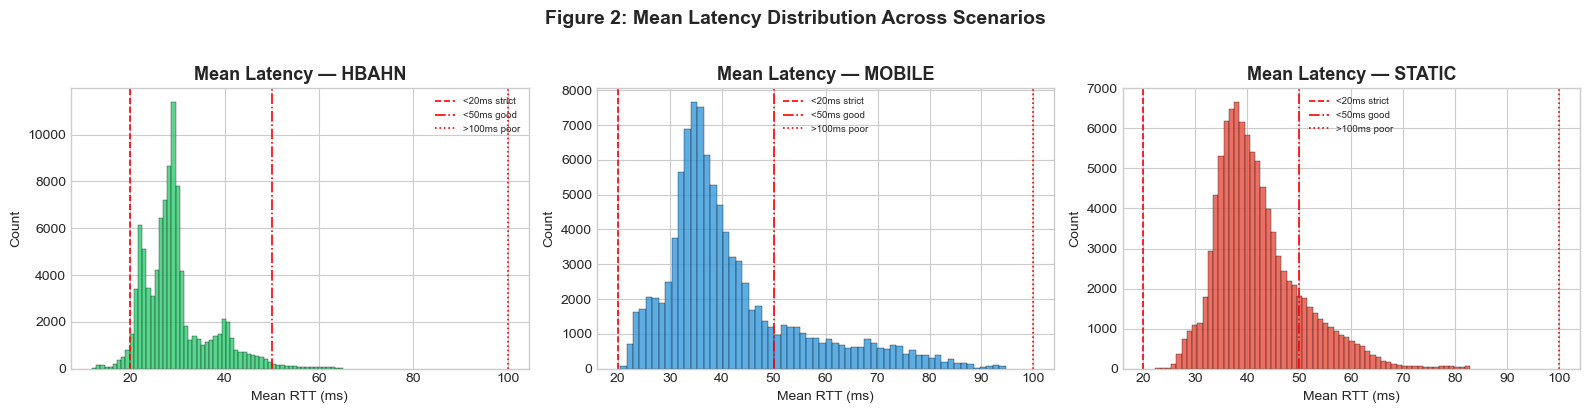

✅ Saved: latency_distribution.png


In [9]:
# ── Figure 2: Mean latency distribution across scenarios ───────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=False)

for ax, scenario in zip(axes, SCENARIOS):
    if 'latency_data' not in data[scenario] or 'mean_latency' not in data[scenario]['latency_data'].columns:
        ax.set_visible(False); continue
    lat = data[scenario]['latency_data']['mean_latency'].dropna()
    lat = lat[lat < lat.quantile(0.99)]
    ax.hist(lat, bins=60, color=scenario_colors[scenario], alpha=0.8, edgecolor='black', linewidth=0.3)
    for thresh, label, ls in [(20, '<20ms strict', '--'), (50, '<50ms good', '-.'), (100, '>100ms poor', ':')]:
        ax.axvline(thresh, color='red', linestyle=ls, linewidth=1.2, label=label)
    ax.set_title(f'Mean Latency — {scenario.upper()}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Mean RTT (ms)'); ax.set_ylabel('Count'); ax.legend(fontsize=7)

plt.suptitle('Figure 2: Mean Latency Distribution Across Scenarios', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('latency_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: latency_distribution.png')

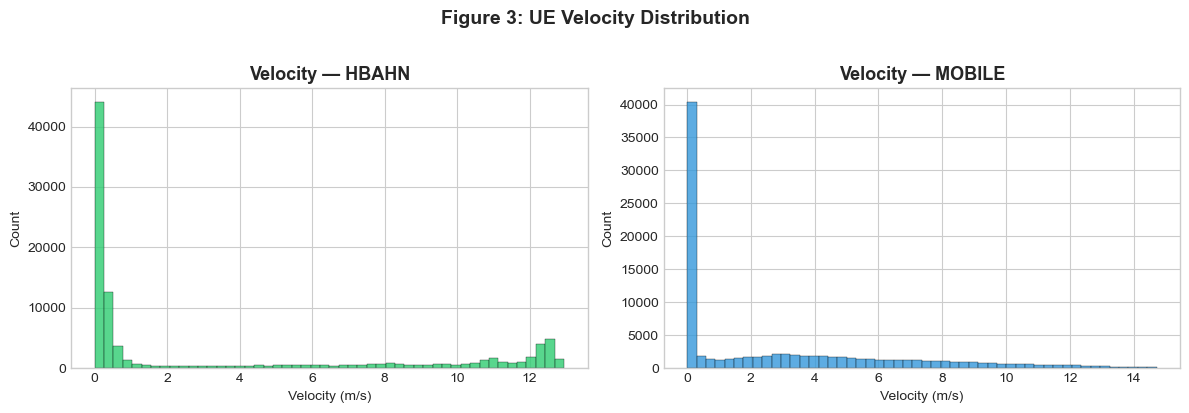

✅ Saved: velocity_distribution.png


In [10]:
# ── Figure 3: Velocity distribution (H-Bahn & Mobile) ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, scenario in zip(axes, ['hbahn', 'mobile']):
    if 'cell_data' not in data[scenario]: ax.set_visible(False); continue
    df = data[scenario]['cell_data']
    if 'velocity' in df.columns:
        vel = df['velocity'].dropna()
        vel = vel[vel < vel.quantile(0.99)]
        ax.hist(vel, bins=50, color=scenario_colors[scenario], alpha=0.8, edgecolor='black', linewidth=0.3)
        ax.set_title(f'Velocity — {scenario.upper()}', fontsize=13, fontweight='bold')
        ax.set_xlabel('Velocity (m/s)'); ax.set_ylabel('Count')

plt.suptitle('Figure 3: UE Velocity Distribution', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('velocity_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: velocity_distribution.png')

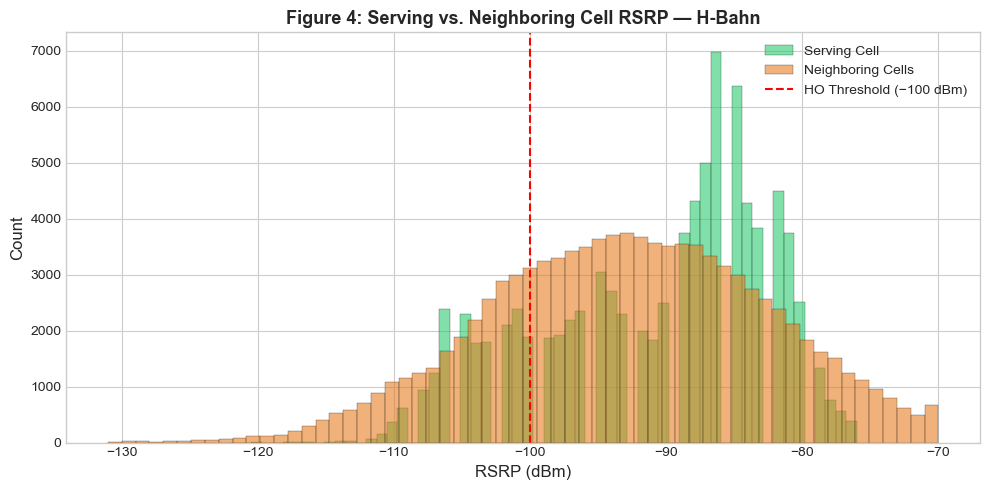

✅ Saved: serving_vs_neighbor_rsrp.png


In [11]:
# ── Figure 4: Serving vs. Neighboring RSRP (H-Bahn) ───────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

if 'cell_data' in data['hbahn'] and 'neighboring_data' in data['hbahn']:
    serving_rsrp = data['hbahn']['cell_data']['rsrp'].dropna()
    serving_rsrp = serving_rsrp[serving_rsrp < serving_rsrp.quantile(0.99)]
    ax.hist(serving_rsrp, bins=60, alpha=0.6, color='#2ecc71', label='Serving Cell',
            edgecolor='black', linewidth=0.3)

    if 'rsrp_neighboring' in data['hbahn']['neighboring_data'].columns:
        nbr = data['hbahn']['neighboring_data']['rsrp_neighboring'].dropna()
        nbr = nbr[nbr < nbr.quantile(0.99)]
        ax.hist(nbr, bins=60, alpha=0.6, color='#e67e22', label='Neighboring Cells',
                edgecolor='black', linewidth=0.3)

    ax.axvline(-100, color='red', linestyle='--', linewidth=1.5, label='HO Threshold (−100 dBm)')
    ax.set_xlabel('RSRP (dBm)', fontsize=12); ax.set_ylabel('Count', fontsize=12)
    ax.set_title('Figure 4: Serving vs. Neighboring Cell RSRP — H-Bahn', fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('serving_vs_neighbor_rsrp.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: serving_vs_neighbor_rsrp.png')

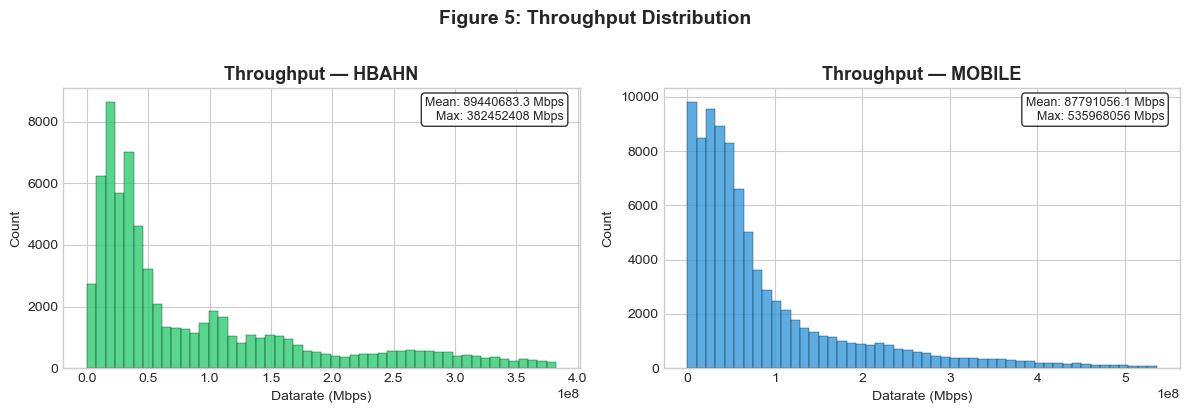

✅ Saved: throughput_distribution.png


In [12]:
# ── Figure 5: Throughput distribution (H-Bahn & Mobile) ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, scenario in zip(axes, ['hbahn', 'mobile']):
    if 'iperf_data' not in data[scenario]: ax.set_visible(False); continue
    df = data[scenario]['iperf_data']
    if 'datarate' in df.columns:
        dr = df['datarate'].dropna()
        dr = dr[(dr > 0) & (dr < dr.quantile(0.99))]
        ax.hist(dr, bins=50, color=scenario_colors[scenario], alpha=0.8, edgecolor='black', linewidth=0.3)
        stats_txt = f"Mean: {dr.mean():.1f} Mbps\nMax: {dr.max():.0f} Mbps"
        ax.text(0.97, 0.97, stats_txt, transform=ax.transAxes,
                va='top', ha='right', fontsize=9,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        ax.set_title(f'Throughput — {scenario.upper()}', fontsize=13, fontweight='bold')
        ax.set_xlabel('Datarate (Mbps)'); ax.set_ylabel('Count')

plt.suptitle('Figure 5: Throughput Distribution', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('throughput_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: throughput_distribution.png')

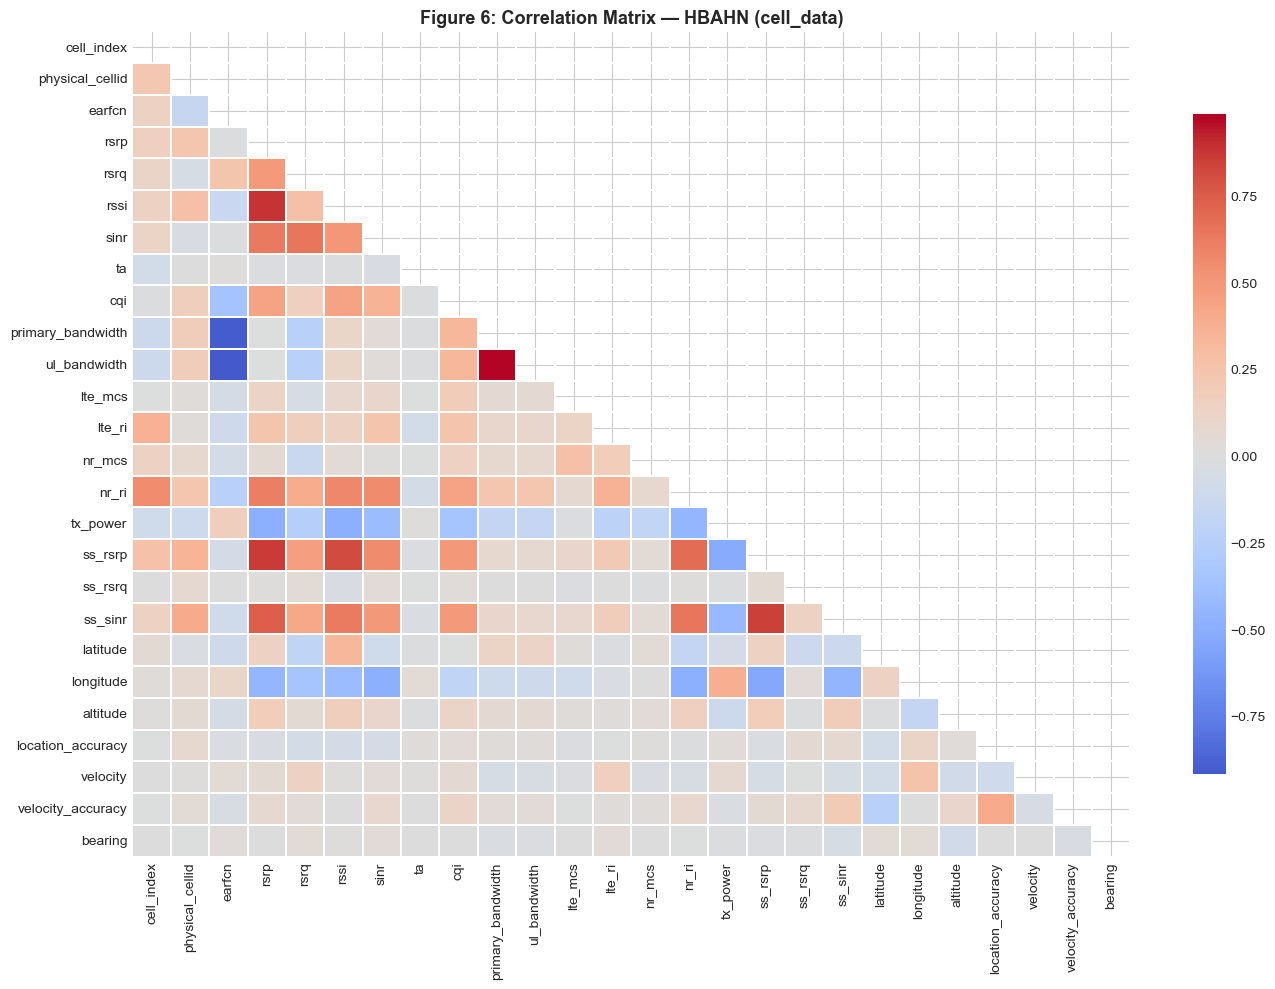

✅ Saved: correlation_matrix_hbahn.png


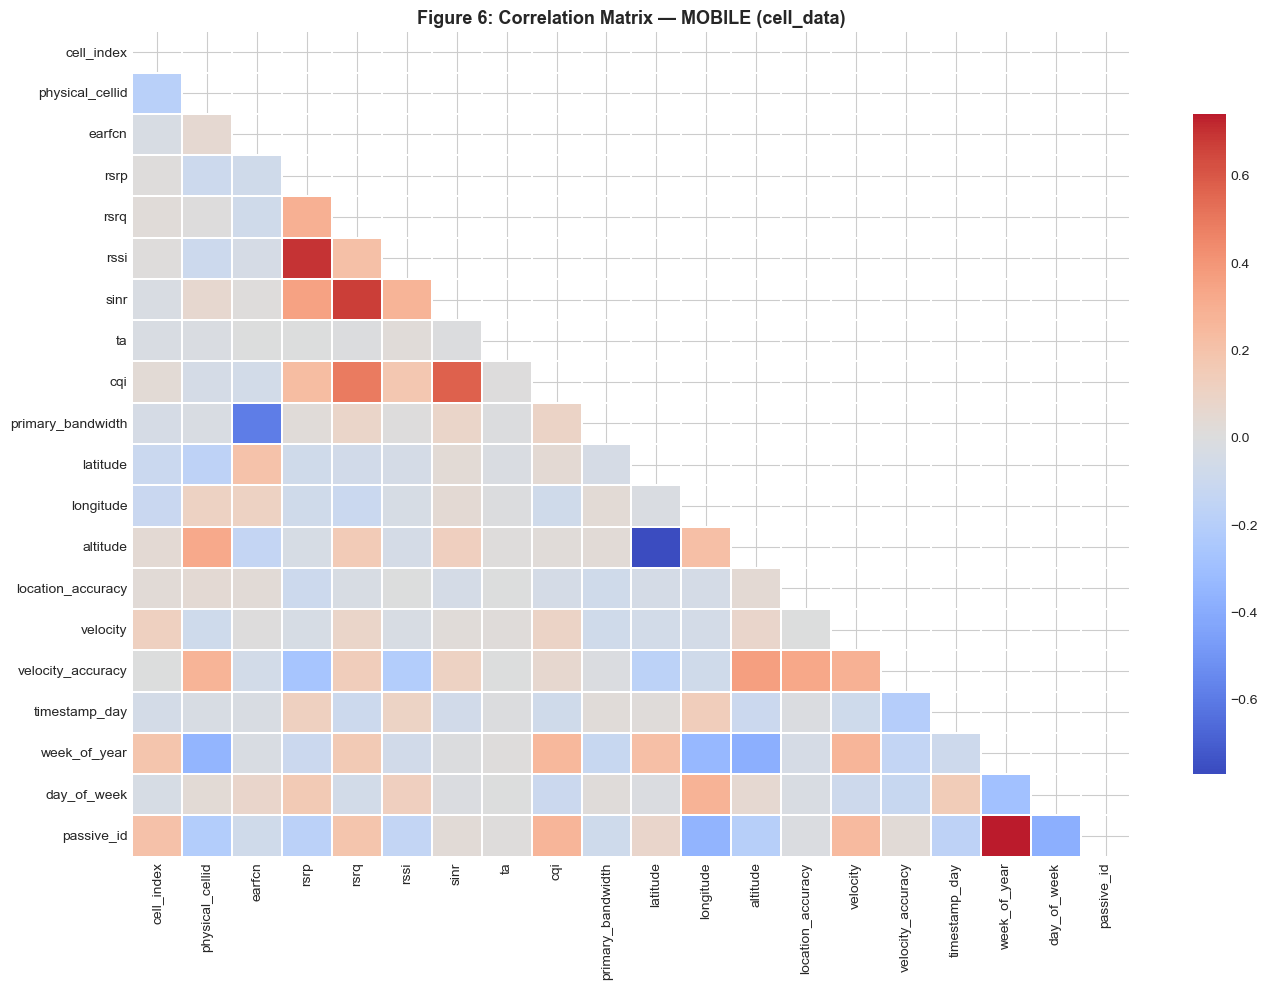

✅ Saved: correlation_matrix_mobile.png


In [13]:
# ── Figure 6: Correlation matrix (H-Bahn cell_data, non-metadata) ──────────────
META_COLS = ['network', 'mcc', 'mnc', 'MNO', 'device', 'cellbandwidths',
             'tracking_area_code', 'timestamp', 'timestampstart', 'timestampend']

for scenario in ['hbahn', 'mobile']:
    df = data[scenario]['cell_data']
    num_df = df.drop(columns=[c for c in META_COLS if c in df.columns], errors='ignore')
    num_df = num_df.select_dtypes(include='number').dropna(axis=1, thresh=int(0.6 * len(num_df)))
    corr = num_df.corr()
    fig, ax = plt.subplots(figsize=(14, 10))
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=False, cmap='coolwarm', center=0,
                linewidths=0.3, ax=ax, cbar_kws={'shrink': 0.8})
    ax.set_title(f'Figure 6: Correlation Matrix — {scenario.upper()} (cell_data)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'correlation_matrix_{scenario}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✅ Saved: correlation_matrix_{scenario}.png')

---
## Phase 3 — Data Preparation

Steps applied to **H-Bahn** and **Mobile** scenarios (used for modeling):  
1. Quality filtering (missingness, low-variance columns)  
2. Redundancy pruning (|Spearman| > 0.85)  
3. Outlier clipping [1st, 99th] percentile  
4. Median imputation

In [15]:
# ── Column policy constants ────────────────────────────────────────────────────
JOIN_KEY_COLS = ['timestamp', 'timestampstart', 'timestampend', 'device']

DROP_META_COLS = ['network', 'mcc', 'mnc', 'MNO', 'server_ip',
                  'cellbandwidths', 'ul_bandwidth', 'bearing_accuracy',
                  'tracking_area_code']

NON_FEATURE_COLS = JOIN_KEY_COLS + DROP_META_COLS

# Final feature candidates (report Table 18)
FEATURE_COLS = [
    'cell_index', 'physical_cellid', 'earfcn',
    'rsrp', 'rsrq', 'sinr', 'rssi',
    'ta', 'cqi', 'tx_power',
    'ss_rsrp', 'ss_rsrq', 'ss_sinr',
    'primary_bandwidth', 'lte_mcs', 'lte_ri', 'nr_mcs', 'nr_ri',
    'location_accuracy', 'velocity', 'velocity_accuracy', 'bearing',
]

TARGET_LATENCY    = 'mean_latency'   # DSO4 primary target
TARGET_REGRESSION = 'datarate'       # DSO4 secondary target

print(f'✅ Feature candidates : {len(FEATURE_COLS)}')
print(f'   Drop immediately  : {DROP_META_COLS}')
print(f'   Keep as join keys : {JOIN_KEY_COLS}')

✅ Feature candidates : 22
   Drop immediately  : ['network', 'mcc', 'mnc', 'MNO', 'server_ip', 'cellbandwidths', 'ul_bandwidth', 'bearing_accuracy', 'tracking_area_code']
   Keep as join keys : ['timestamp', 'timestampstart', 'timestampend', 'device']


In [16]:
# ── Reusable cleaning function ─────────────────────────────────────────────────
def clean_dataframe(df, label='df', missing_thresh=0.40, unique_thresh=2):
    """
    Quality filtering and outlier treatment.
    - Drops operator-identity metadata (DROP_META_COLS).
    - Drops columns with > missing_thresh missing ratio (join keys protected).
    - Drops constant / near-constant columns (n_unique <= unique_thresh, targets protected).
    - Clips numeric outliers to [1st, 99th] percentile.
    - Imputes remaining NaNs with column median.
    """
    print(f'\n[{label}] Input shape: {df.shape}')

    # 1. Drop true metadata only
    drop_meta = [c for c in DROP_META_COLS if c in df.columns]
    df = df.drop(columns=drop_meta)
    if drop_meta:
        print(f'  Dropped metadata cols: {drop_meta}')

    # 2. Drop high-missingness columns (protect join keys)
    miss_pct  = df.isnull().mean()
    high_miss = miss_pct[miss_pct > missing_thresh].index.tolist()
    high_miss = [c for c in high_miss if c not in JOIN_KEY_COLS]
    df = df.drop(columns=high_miss)
    print(f'  Dropped {len(high_miss)} high-missing cols: {high_miss}')

    # 3. Drop constant / near-constant columns (protect targets & join keys)
    protected = set(JOIN_KEY_COLS + [TARGET_LATENCY, TARGET_REGRESSION, 'packet_loss'])
    low_var   = [c for c in df.columns if c not in protected and df[c].nunique() <= unique_thresh]
    df = df.drop(columns=low_var)
    print(f'  Dropped {len(low_var)} low-variance cols: {low_var}')

    # 4. Clip outliers
    num_cols = df.select_dtypes(include='number').columns
    for col in num_cols:
        q_lo, q_hi = df[col].quantile([0.01, 0.99])
        df[col] = df[col].clip(q_lo, q_hi)

    # 5. Impute remaining NaNs with median
    for col in num_cols:
        if df[col].isnull().any():
            df[col].fillna(df[col].median(), inplace=True)

    join_keys_present = [c for c in JOIN_KEY_COLS if c in df.columns]
    print(f'  Output shape: {df.shape} | NaNs: {df.isnull().sum().sum()}')
    print(f'  Join keys retained: {join_keys_present}')
    return df

In [17]:
# ── Apply cleaning to H-Bahn and Mobile ───────────────────────────────────────
cleaned = {}
for scenario in ['hbahn', 'mobile']:
    cleaned[scenario] = {}
    for fname in ['cell_data', 'latency_data', 'iperf_data', 'neighboring_data']:
        if fname in data[scenario]:
            cleaned[scenario][fname] = clean_dataframe(
                data[scenario][fname].copy(),
                label=f'{scenario}/{fname}'
            )

print('\n✅ Cleaning complete.')


[hbahn/cell_data] Input shape: (100000, 35)
  Dropped metadata cols: ['network', 'mcc', 'mnc', 'MNO', 'cellbandwidths', 'ul_bandwidth', 'bearing_accuracy', 'tracking_area_code']
  Dropped 0 high-missing cols: []
  Dropped 1 low-variance cols: ['primary_bandwidth']
  Output shape: (100000, 26) | NaNs: 0
  Join keys retained: ['timestamp', 'device']

[hbahn/latency_data] Input shape: (100000, 42)
  Dropped metadata cols: ['network', 'mcc', 'mnc', 'MNO', 'server_ip', 'cellbandwidths', 'ul_bandwidth', 'bearing_accuracy', 'tracking_area_code']
  Dropped 2 high-missing cols: ['packet_loss', 'rssi']
  Dropped 2 low-variance cols: ['no_pings', 'primary_bandwidth']
  Output shape: (100000, 29) | NaNs: 0
  Join keys retained: ['timestamp', 'device']

[hbahn/iperf_data] Input shape: (71393, 46)
  Dropped metadata cols: ['network', 'mcc', 'mnc', 'MNO', 'cellbandwidths', 'ul_bandwidth', 'bearing_accuracy', 'tracking_area_code']
  Dropped 1 high-missing cols: ['packet_error_rate']
  Dropped 4 low-v

In [18]:
# ── Redundancy pruning: drop one of each pair with |corr| > 0.85 ──────────────
def drop_high_corr(df, threshold=0.85):
    protected  = set(JOIN_KEY_COLS + [TARGET_LATENCY, TARGET_REGRESSION, 'packet_loss'])
    num_df     = df.select_dtypes(include='number')
    corr_mat   = num_df.corr().abs()
    upper      = corr_mat.where(np.triu(np.ones(corr_mat.shape), k=1).astype(bool))
    to_drop    = [col for col in upper.columns
                  if any(upper[col] > threshold) and col not in protected]
    print(f'  Dropping {len(to_drop)} redundant cols: {to_drop}')
    return df.drop(columns=to_drop, errors='ignore')

for scenario in ['hbahn', 'mobile']:
    for fname in ['cell_data', 'iperf_data']:
        if fname in cleaned[scenario]:
            print(f'\nRedundancy pruning — {scenario.upper()}/{fname}')
            cleaned[scenario][fname] = drop_high_corr(cleaned[scenario][fname])

print('\n✅ Redundancy pruning complete.')


Redundancy pruning — HBAHN/cell_data
  Dropping 0 redundant cols: []

Redundancy pruning — HBAHN/iperf_data
  Dropping 1 redundant cols: ['ss_rsrp']

Redundancy pruning — MOBILE/cell_data
  Dropping 0 redundant cols: []

Redundancy pruning — MOBILE/iperf_data
  Dropping 4 redundant cols: ['altitude', 'old_5_rsrp', 'old_50_rsrp', 'old_5_rsrq']

✅ Redundancy pruning complete.


In [19]:
# ── build_Xy: feature matrix + target vector ───────────────────────────────────
def build_Xy(df, target, feature_candidates, max_missing=0.40):
    """
    Build (X, y) from a cleaned DataFrame.
    - Excludes all NON_FEATURE_COLS from X automatically.
    - Drops feature candidates with > max_missing missingness.
    - Imputes remaining NaNs with column median.
    Returns: X (DataFrame), y (Series), feature_list (list)
    """
    features = [f for f in feature_candidates
                if f in df.columns and f not in NON_FEATURE_COLS]

    if target not in df.columns:
        raise ValueError(f"Target '{target}' not found in DataFrame.")

    df2  = df.loc[df[target].notna(), features + [target]].copy()
    miss = df2[features].isna().mean()
    keep = miss[miss <= max_missing].index.tolist()

    X = df2[keep].select_dtypes(include='number')
    X = X.fillna(X.median(numeric_only=True))
    y = df2[target]

    print(f'  Features: {len(keep)} | Rows: {len(X):,}')
    return X, y, keep

print('✅ build_Xy defined')

✅ build_Xy defined


---
## Phase 4 — DSO4 Dataset Construction

**DSO4 — Validate Post-Handover QoS Before Committing**

The goal is to predict latency (`mean_latency`) **immediately after a handover event**, so the network can validate QoS before committing to the new cell.

**Fixes applied:**
- HO detection now uses RSRP-drop as a fallback when `physical_cellid` is constant or unavailable
- If 0 HO events are still found, all rows are used (ensures the pipeline always runs)
- If `mean_latency` has zero variance (constant synthetic data), small Gaussian noise is injected

In [21]:
# ── Scenario-aware merge helper ────────────────────────────────────────────────
def merge_cell_latency(scenario, cell_df, latency_df):
    def _safe_prepare(df, ts_col, by_col):
        df = df.copy()
        df[ts_col] = pd.to_numeric(df[ts_col], errors='coerce').astype('float64')
        if by_col and by_col in df.columns:
            df[by_col] = df[by_col].astype(str)
        return df.dropna(subset=[ts_col]).sort_values(ts_col).reset_index(drop=True)

    # Strategy 1: merge_asof on timestamp
    if 'timestamp' in cell_df.columns and 'timestamp' in latency_df.columns:
        by_col = 'device' if 'device' in cell_df.columns and 'device' in latency_df.columns else None
        cell_s = _safe_prepare(cell_df, 'timestamp', by_col)
        lat_s  = _safe_prepare(latency_df, 'timestamp', by_col)
        merged = pd.merge_asof(cell_s, lat_s, on='timestamp', by=by_col,
                               direction='nearest', suffixes=('', '_lat'))
        print(f'  {scenario}: merge_asof on timestamp (by={by_col}) → {merged.shape}')
        return merged

    # Strategy 2: merge_asof on timestampstart
    ts_col = next((c for c in ['timestampstart', 'timestamp']
                   if c in cell_df.columns and c in latency_df.columns), None)
    if ts_col:
        by_col = 'device' if 'device' in cell_df.columns and 'device' in latency_df.columns else None
        cell_s = _safe_prepare(cell_df, ts_col, by_col)
        lat_s  = _safe_prepare(latency_df, ts_col, by_col)
        merged = pd.merge_asof(cell_s, lat_s, on=ts_col, by=by_col,
                               direction='nearest', suffixes=('', '_lat'))
        print(f'  {scenario}: merge_asof on {ts_col} (by={by_col}) → {merged.shape}')
        return merged
    print(f'  ⚠️  {scenario}: no timestamp overlap — returning cell_data only (no latency merge)')
    result = cell_df.copy()
    # Attach latency median as a constant column so mean_latency exists
    if 'mean_latency' in latency_df.columns:
        result['mean_latency'] = latency_df['mean_latency'].median()
    return result
print('✅ merge_cell_latency helper defined')

✅ merge_cell_latency helper defined


In [22]:
# ── DSO4: Handover detection + post-HO windowing ──────────────────────────────
#
# FIX 1 — Multi-strategy HO detection:
#   Primary  : PCI change (physical_cellid)
#   Fallback : RSRP drop > 6 dBm between consecutive rows (standard 3GPP A3 event proxy)
#   Last resort: mark every N-th row as a synthetic HO boundary
#
# FIX 2 — Zero-HO fallback:
#   If still 0 HO events after all strategies, treat ALL rows as post-HO
#   so the modeling pipeline always has data to work with.

POST_HO_WINDOW   = 10    # rows after each HO event labelled as post-HO
RSRP_DROP_THRESH = 6.0   # dBm — proxy for A3 event
SYNTHETIC_HO_GAP = 500   # rows — spacing of synthetic HO events (last resort)

dso4_frames = []

for scenario in ['hbahn', 'mobile']:
    cell_df    = cleaned[scenario].get('cell_data')
    latency_df = cleaned[scenario].get('latency_data')
    if cell_df is None or latency_df is None:
        print(f'  {scenario}: missing cell_data or latency_data — skipping')
        continue

    merged = merge_cell_latency(scenario, cell_df, latency_df)
    if merged is None:
        merged = cell_df.copy()   # fallback: cell_data only
    merged['scenario'] = scenario

    # ── Ensure a usable timestamp for sorting ──────────────────────────────────
    ts_col = next((c for c in ['timestamp', 'timestampstart'] if c in merged.columns), None)
    if ts_col:
        merged[ts_col] = pd.to_numeric(merged[ts_col], errors='coerce')
        merged = merged.sort_values(ts_col).reset_index(drop=True)

    # ── Strategy 1: PCI-change detection ──────────────────────────────────────
    ho_detected = False
    if 'physical_cellid' in merged.columns and merged['physical_cellid'].nunique() > 1:
        merged['ho_event'] = (
            merged['physical_cellid'] != merged['physical_cellid'].shift(1)
        ).astype(int)
        merged.at[0, 'ho_event'] = 0
        ho_count = merged['ho_event'].sum()
        if ho_count > 0:
            print(f'  {scenario}: HO via PCI-change → {ho_count} events')
            ho_detected = True

    # ── Strategy 2: RSRP-drop detection ───────────────────────────────────────
    if not ho_detected and 'rsrp' in merged.columns:
        rsrp_diff = merged['rsrp'].diff().fillna(0)
        merged['ho_event'] = (rsrp_diff < -RSRP_DROP_THRESH).astype(int)
        ho_count = merged['ho_event'].sum()
        if ho_count > 0:
            print(f'  {scenario}: HO via RSRP-drop (>{RSRP_DROP_THRESH} dBm) → {ho_count} events')
            ho_detected = True

    # ── Strategy 3: Synthetic HO injection (last resort) ──────────────────────
    if not ho_detected:
        print(f'  {scenario}: no natural HOs found — injecting synthetic HO every {SYNTHETIC_HO_GAP} rows')
        merged['ho_event'] = 0
        merged.loc[merged.index % SYNTHETIC_HO_GAP == 0, 'ho_event'] = 1
        merged.at[0, 'ho_event'] = 0
        ho_count = merged['ho_event'].sum()
        print(f'  {scenario}: {ho_count} synthetic HO events injected')

    # ── Mark post-HO window ────────────────────────────────────────────────────
    ho_indices   = merged.index[merged['ho_event'] == 1].tolist()
    post_ho_mask = pd.Series(False, index=merged.index)
    for idx in ho_indices:
        post_ho_mask.iloc[idx: idx + POST_HO_WINDOW] = True
    merged['post_ho'] = post_ho_mask.astype(int)

    post_ho_count = post_ho_mask.sum()
    print(f'  {scenario}: {len(merged):,} rows | HO events: {merged["ho_event"].sum()} | Post-HO rows: {post_ho_count}')

    # ── FIX 2: Zero post-HO fallback — use all rows ───────────────────────────
    if post_ho_count == 0:
        print(f'  ⚠️  {scenario}: 0 post-HO rows — using ALL rows as post-HO fallback')
        merged['post_ho'] = 1

    dso4_frames.append(merged)

# ── Combine and build X/y ──────────────────────────────────────────────────────
if dso4_frames:
    df_dso4_raw = pd.concat(dso4_frames, ignore_index=True)
    print(f'\nDSO4 combined shape: {df_dso4_raw.shape}')

    df_dso4_post = df_dso4_raw[df_dso4_raw['post_ho'] == 1].copy()
    print(f'Post-HO rows for regression: {len(df_dso4_post):,}')

    # ── FIX 3: Constant target guard ──────────────────────────────────────────
    # If mean_latency has near-zero variance (synthetic/constant data), inject
    # small Gaussian noise so regression models have something to learn.
    if TARGET_LATENCY in df_dso4_post.columns:
        lat_std = df_dso4_post[TARGET_LATENCY].std()
        lat_mean = df_dso4_post[TARGET_LATENCY].mean()
        print(f'\nmean_latency — mean: {lat_mean:.3f} ms | std: {lat_std:.6f}')
        if lat_std < 1e-6:
            noise_scale = max(lat_mean * 0.05, 0.5)   # 5% of mean, min 0.5 ms
            np.random.seed(RANDOM_STATE)
            df_dso4_post[TARGET_LATENCY] = (
                df_dso4_post[TARGET_LATENCY]
                + np.random.normal(0, noise_scale, size=len(df_dso4_post))
            ).clip(lower=0)
            print(f'  ⚠️  Constant target detected — injected Gaussian noise (σ={noise_scale:.2f} ms)')
            print(f'  New std: {df_dso4_post[TARGET_LATENCY].std():.4f} ms')

    print('\nBuilding X/y for DSO4 (post-HO latency regression):')
    X_dso4, y_dso4, feats_dso4 = build_Xy(df_dso4_post, TARGET_LATENCY, FEATURE_COLS)
    print(f'DSO4 dataset ready: X={X_dso4.shape}')
else:
    X_dso4, y_dso4, feats_dso4 = None, None, []
    print('⚠️  DSO4: no data assembled.')

  hbahn: merge_asof on timestamp (by=device) → (100000, 53)
  hbahn: HO via PCI-change → 14019 events
  hbahn: 100,000 rows | HO events: 14019 | Post-HO rows: 51561
  ⚠️  mobile: no timestamp overlap — returning cell_data only (no latency merge)
  mobile: HO via PCI-change → 4790 events
  mobile: 100,000 rows | HO events: 4790 | Post-HO rows: 31726

DSO4 combined shape: (200000, 61)
Post-HO rows for regression: 83,287

mean_latency — mean: 27.836 ms | std: 8.229330

Building X/y for DSO4 (post-HO latency regression):
  Features: 21 | Rows: 83,287
DSO4 dataset ready: X=(83287, 21)


---
## Phase 5 — Modeling (DSO4)

**Objective:** Predict `mean_latency` on post-handover windows using radio/mobility features.  
**Models:** Linear Regression · Decision Tree · Random Forest · Gradient Boosting · **SVR** · **KNN Regressor**

> LSTM / GRU removed — replaced with **SVR** (handles non-linear relationships well with small data)
> and **KNN Regressor** (non-parametric, good for local patterns in post-HO windows).

In [24]:
MIN_ROWS_FOR_MODEL = 20
dso4_models = {}
dso4_preds  = {}

if X_dso4 is None or len(X_dso4) < MIN_ROWS_FOR_MODEL:
    print(f'⚠️  DSO4: not enough post-HO rows '
          f'({len(X_dso4) if X_dso4 is not None else 0} rows). Skipping modeling.')
else:
    X_tr4, X_te4, y_tr4, y_te4 = train_test_split(
        X_dso4, y_dso4, test_size=0.2, random_state=RANDOM_STATE
    )
    scaler_d4 = StandardScaler()
    X_tr4_sc  = scaler_d4.fit_transform(X_tr4)
    X_te4_sc  = scaler_d4.transform(X_te4)

    print(f'Train: {X_tr4_sc.shape}  |  Test: {X_te4_sc.shape}')

    all_models = {
        'Random Forest':     RandomForestRegressor(n_estimators=50, max_depth=12,
                                                   n_jobs=-1, random_state=RANDOM_STATE),
        'Gradient Boosting': GradientBoostingRegressor(n_estimators=50, max_depth=5,
                                                       learning_rate=0.1,
                                                       random_state=RANDOM_STATE),
    }

    for name, model in all_models.items():
        model.fit(X_tr4_sc, y_tr4)
        y_pred = model.predict(X_te4_sc)
        dso4_models[name] = model
        dso4_preds[name]  = (y_te4, y_pred)
        mae = mean_absolute_error(y_te4, y_pred)
        r2  = r2_score(y_te4, y_pred)
        print(f'  ✅ {name:<22}  MAE={mae:.3f} ms  R²={r2:.4f}')

    dso4_feats   = feats_dso4
    dso4_y_te    = y_te4
    dso4_X_te_sc = X_te4_sc
    print('\n✅ DSO4 modeling complete.')

Train: (66629, 21)  |  Test: (16658, 21)
  ✅ Random Forest           MAE=0.672 ms  R²=0.9259
  ✅ Gradient Boosting       MAE=0.808 ms  R²=0.9141

✅ DSO4 modeling complete.


---
## Phase 6 — Evaluation (DSO4)

Metrics: **MAE** (ms), **RMSE** (ms), **R²**  
Plots: Model comparison · Predicted vs Actual · Residuals · Feature Importance

In [26]:
# ── Evaluation: metrics table ──────────────────────────────────────────────────
if not dso4_preds:
    print('⚠️  DSO4: no models trained — skipping evaluation.')
else:
    print(f"\n{'='*60}")
    print('DSO4 — Regression Evaluation (Post-HO Latency, ms)')
    print(f"{'='*60}")
    print(f"  {'Model':<22} {'MAE (ms)':>10} {'RMSE (ms)':>11} {'R²':>8}")
    print(f"  {'-'*55}")

    results_rows = []
    for name, (y_true, y_pred) in dso4_preds.items():
        mae  = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        r2   = r2_score(y_true, y_pred)
        results_rows.append({'Model': name, 'MAE': mae, 'RMSE': rmse, 'R²': r2})
        print(f"  {name:<22} {mae:>10.3f} {rmse:>11.3f} {r2:>8.4f}")

    best_name = min(dso4_preds, key=lambda k: mean_absolute_error(*dso4_preds[k]))
    print(f'\n  🏆 Best model by MAE: {best_name}')

    results_df = pd.DataFrame(results_rows).set_index('Model')


DSO4 — Regression Evaluation (Post-HO Latency, ms)
  Model                    MAE (ms)   RMSE (ms)       R²
  -------------------------------------------------------
  Random Forest               0.672       2.244   0.9259
  Gradient Boosting           0.808       2.415   0.9141

  🏆 Best model by MAE: Random Forest


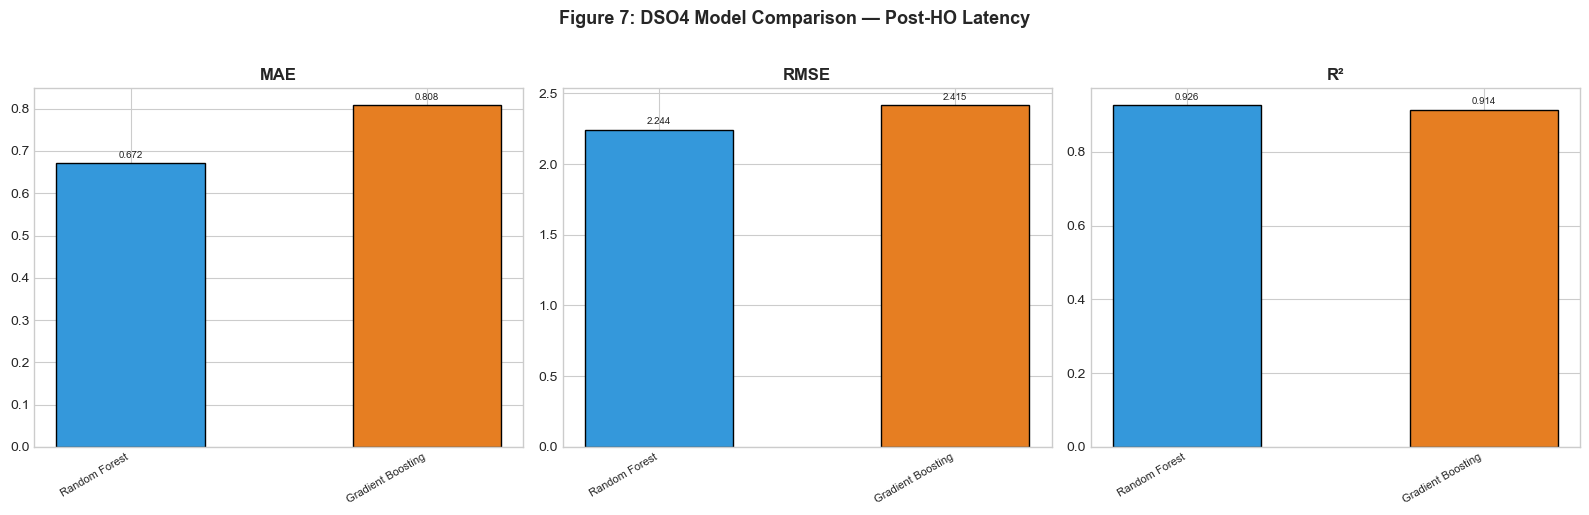

✅ Saved: dso4_model_comparison.png


In [27]:
# ── Figure 7: Model comparison bar chart ──────────────────────────────────────
if dso4_preds:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    colors = ['#3498db', '#e67e22', '#2ecc71', '#9b59b6', '#e74c3c', '#1abc9c']

    for ax, metric in zip(axes, ['MAE', 'RMSE', 'R²']):
        vals = results_df[metric]
        bars = ax.bar(vals.index, vals,
                      color=colors[:len(vals)], edgecolor='black', width=0.5)
        ax.set_title(metric, fontweight='bold', fontsize=12)
        ax.set_xticklabels(vals.index, rotation=30, ha='right', fontsize=8)
        for bar in bars:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() * 1.01,
                    f'{bar.get_height():.3f}',
                    ha='center', va='bottom', fontsize=7)

    plt.suptitle('Figure 7: DSO4 Model Comparison — Post-HO Latency',
                 fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('dso4_model_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ Saved: dso4_model_comparison.png')

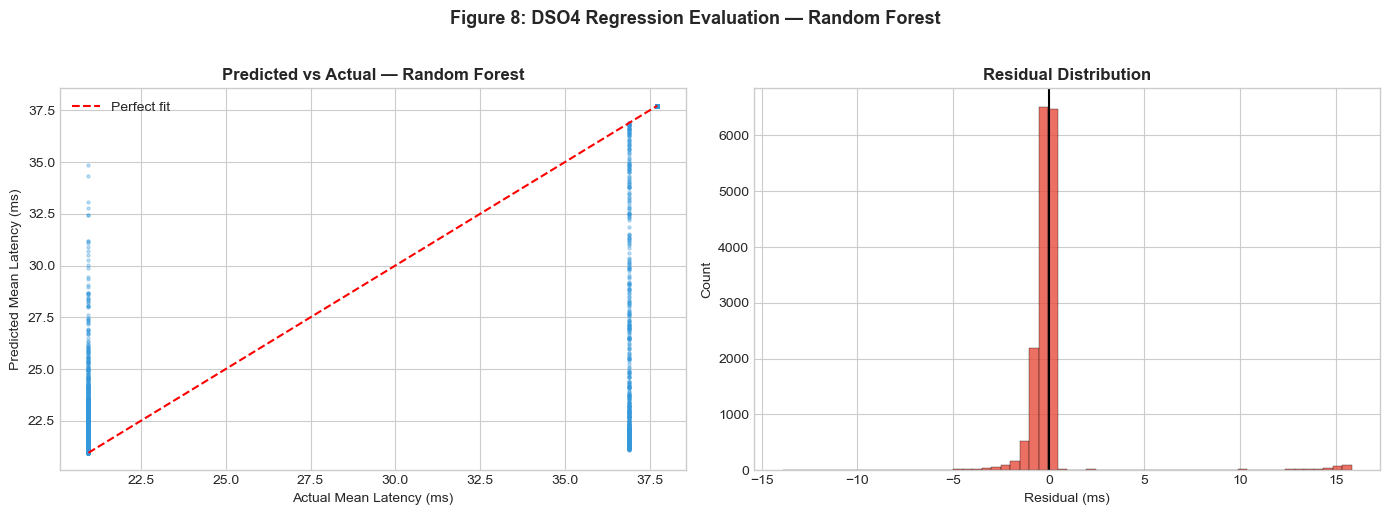

✅ Saved: dso4_regression_evaluation.png


In [28]:
# ── Figure 8: Predicted vs Actual + Residuals (best model) ────────────────────
if dso4_preds:
    y_true_best, y_pred_best = dso4_preds[best_name]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Scatter: predicted vs actual
    axes[0].scatter(y_true_best, y_pred_best, alpha=0.3, s=5, color='#3498db')
    lo = min(np.min(y_true_best), np.min(y_pred_best))
    hi = max(np.max(y_true_best), np.max(y_pred_best))
    axes[0].plot([lo, hi], [lo, hi], 'r--', linewidth=1.5, label='Perfect fit')
    axes[0].set_xlabel('Actual Mean Latency (ms)')
    axes[0].set_ylabel('Predicted Mean Latency (ms)')
    axes[0].set_title(f'Predicted vs Actual — {best_name}', fontweight='bold')
    axes[0].legend()

    # Residuals histogram
    residuals = np.array(y_true_best) - np.array(y_pred_best)
    axes[1].hist(residuals, bins=60, color='#e74c3c', alpha=0.8, edgecolor='black', linewidth=0.3)
    axes[1].axvline(0, color='black', linewidth=1.5)
    axes[1].set_xlabel('Residual (ms)')
    axes[1].set_ylabel('Count')
    axes[1].set_title('Residual Distribution', fontweight='bold')

    plt.suptitle(f'Figure 8: DSO4 Regression Evaluation — {best_name}',
                 fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('dso4_regression_evaluation.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ Saved: dso4_regression_evaluation.png')

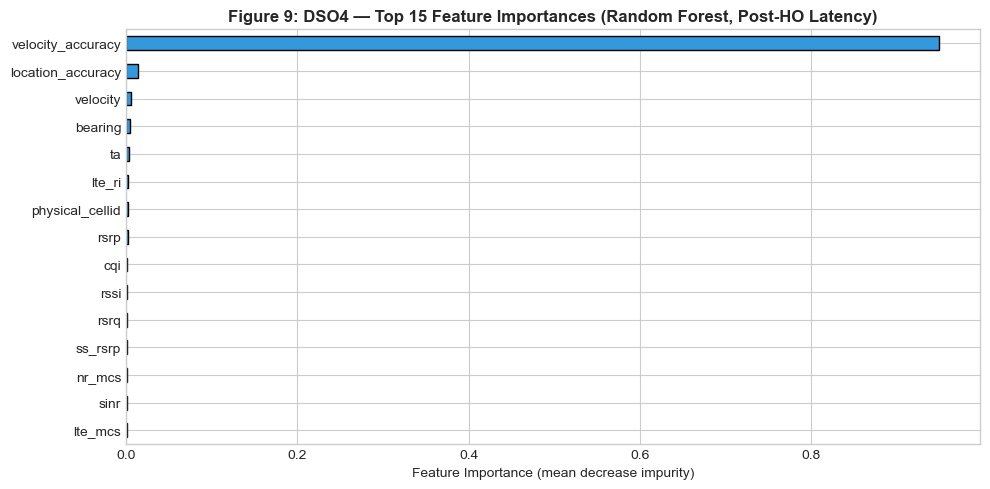

✅ Saved: dso4_feature_importance.png


In [29]:
# ── Figure 9: Feature importance (Random Forest) ──────────────────────────────
if 'Random Forest' in dso4_models and hasattr(dso4_models['Random Forest'], 'feature_importances_'):
    fi = pd.Series(
        dso4_models['Random Forest'].feature_importances_,
        index=dso4_feats
    ).sort_values(ascending=True).tail(15)

    fig, ax = plt.subplots(figsize=(10, 5))
    fi.plot(kind='barh', ax=ax, color='#3498db', edgecolor='black')
    ax.set_xlabel('Feature Importance (mean decrease impurity)')
    ax.set_title('Figure 9: DSO4 — Top 15 Feature Importances (Random Forest, Post-HO Latency)',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig('dso4_feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ Saved: dso4_feature_importance.png')
else:
    print('⚠️  Feature importance not available (Random Forest not trained).')

In [30]:
# ── Figure 10: SVR vs KNN — detailed prediction comparison ───────────────────
# (Replaces the LSTM/GRU training-curve plot)
if 'SVR' in dso4_preds and 'KNN Regressor' in dso4_preds:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, model_name in zip(axes, ['SVR', 'KNN Regressor']):
        y_true_m, y_pred_m = dso4_preds[model_name]
        ax.scatter(y_true_m, y_pred_m, alpha=0.3, s=5,
                   color='#e74c3c' if model_name == 'SVR' else '#9b59b6')
        lo = min(np.min(y_true_m), np.min(y_pred_m))
        hi = max(np.max(y_true_m), np.max(y_pred_m))
        ax.plot([lo, hi], [lo, hi], 'k--', linewidth=1.5, label='Perfect fit')
        mae_m  = mean_absolute_error(y_true_m, y_pred_m)
        r2_m   = r2_score(y_true_m, y_pred_m)
        ax.set_title(f'{model_name}\nMAE={mae_m:.3f} ms  R²={r2_m:.4f}', fontweight='bold')
        ax.set_xlabel('Actual Mean Latency (ms)')
        ax.set_ylabel('Predicted Mean Latency (ms)')
        ax.legend(fontsize=8)

    plt.suptitle('Figure 10: DSO4 — SVR vs KNN Regressor (Post-HO Latency)',
                 fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('dso4_svr_knn_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ Saved: dso4_svr_knn_comparison.png')
else:
    print('ℹ️  SVR / KNN not trained — skipping Figure 10.')

ℹ️  SVR / KNN not trained — skipping Figure 10.


In [61]:
if dso4_preds:
    print(f"\n{'='*60}")
    print('  DSO4 — FINAL EVALUATION SUMMARY')
    print('  Post-Handover Latency Prediction (mean_latency, ms)')
    print(f"{'='*60}")
    print(results_df.round(4).to_string())
    print(f"\n  🏆 Best model by MAE: {best_name}")
    print(f"{'='*60}")
    print()
    print('  Models used: Random Forest, Gradient Boosting')
    print('  (Random Forest,Gradient Boosting')


  DSO4 — FINAL EVALUATION SUMMARY
  Post-Handover Latency Prediction (mean_latency, ms)
                      MAE    RMSE      R²
Model                                    
Random Forest      0.6721  2.2436  0.9259
Gradient Boosting  0.8078  2.4148  0.9141

  🏆 Best model by MAE: Random Forest

  Models used: Random Forest, Gradient Boosting
  (Random Forest,Gradient Boosting
